# Raport z Eksploracyjnej Analizy Danych (EDA)
**Projekt:** Detekcja celowo zawyżonych cen (anomalii) w ofertach noclegowych (blokowanie kalendarza)

## Cel analizy
Zgodnie z wymaganiami etapu 1 (punkt a.ii), poniższy dokument przedstawia weryfikację dostarczonych zbiorów danych pod kątem ich przydatności do realizacji zadania modelowania. 
Sprawdzamy tutaj:
1. Jakość i kompletność danych (braki w kolumnach).
2. Spójność relacyjną między tabelami i zakresy czasowe.
3. Zachowanie zmiennej docelowej (jak cena wpływa na konwersję z wyświetleń na rezerwacje).

Na końcu notatnika znajduje się **ostateczna ocena biznesowa** odpowiadająca na pytanie, czy dostarczone dane są wystarczające i co ewentualnie należy w nich poprawić.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Jakość i kompletność danych (Analiza braków)
W pierwszej kolejności weryfikujemy, w jakim stopniu poszczególne tabele są uzupełnione. Pozwoli to odrzucić cechy, które niosą zbyt mało informacji z powodu braków.

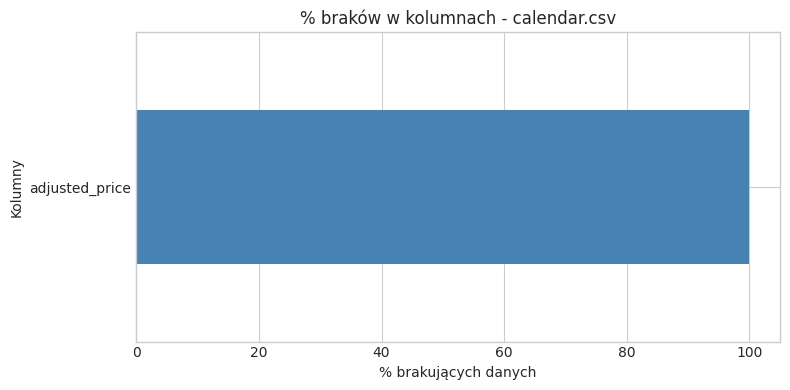

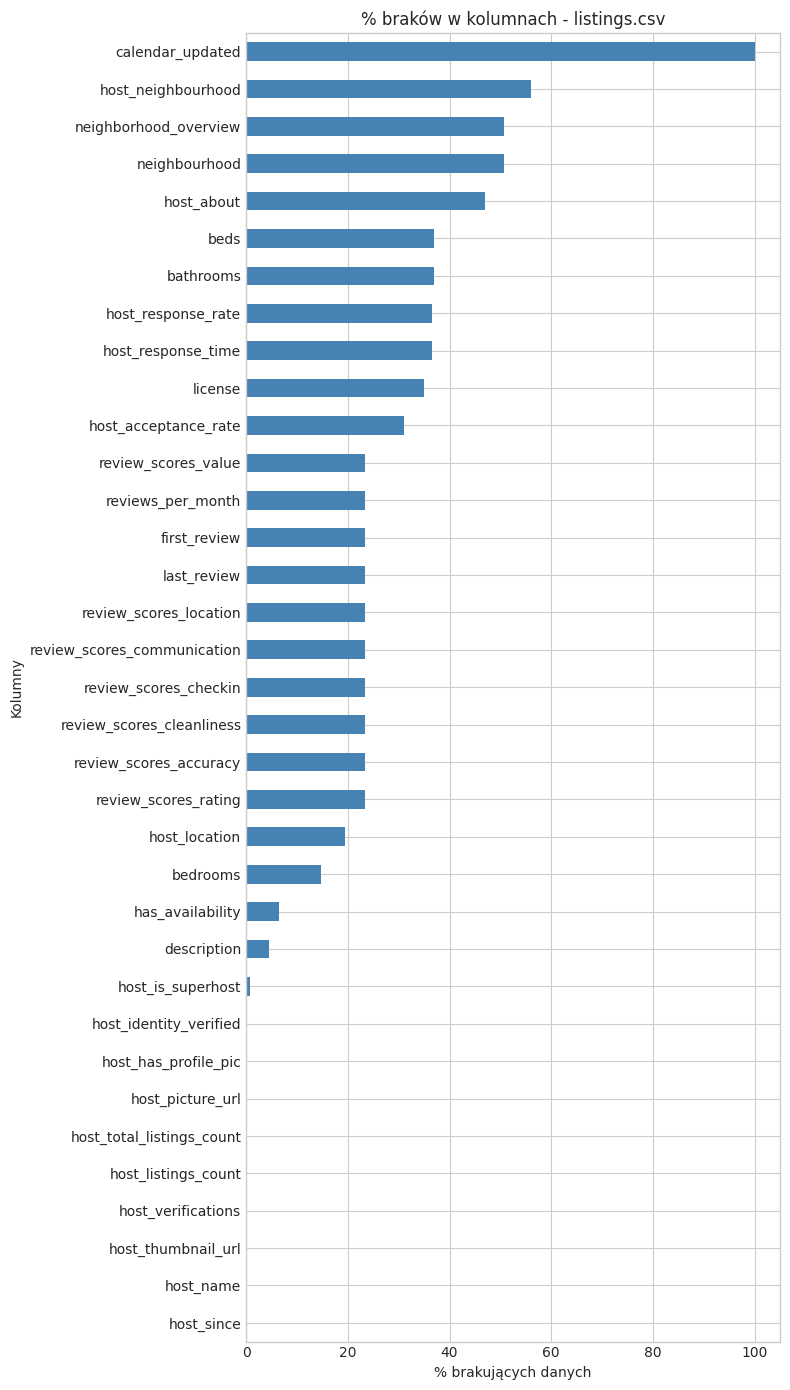

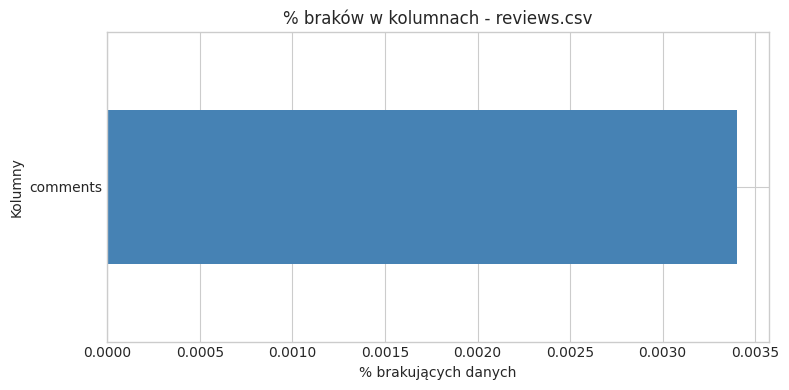

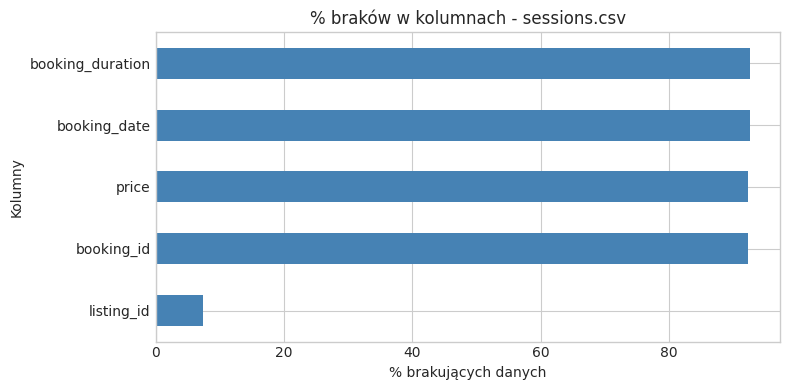

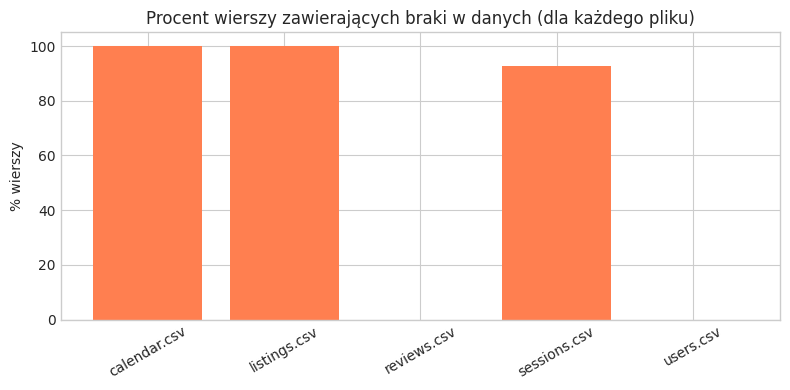

In [9]:
files = ["calendar.csv", "listings.csv", "reviews.csv", "sessions.csv", "users.csv"]
rows_missing_summary = {}

for file in files:
    df = pd.read_csv("data/" + file)
    missing_col_percent = df.isna().mean() * 100
    missing_col_percent = missing_col_percent[missing_col_percent > 0]
    
    rows_with_missing = df.isna().any(axis=1).mean() * 100
    rows_missing_summary[file] = rows_with_missing
    
    if not missing_col_percent.empty:
        fig_height = max(4, len(missing_col_percent) * 0.4)
        plt.figure(figsize=(8, fig_height))
        missing_col_percent.sort_values().plot(kind="barh", color='steelblue')
        plt.title(f"% braków w kolumnach - {file}")
        plt.xlabel("% brakujących danych")
        plt.ylabel("Kolumny")
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(8, 4))
plt.bar(rows_missing_summary.keys(), rows_missing_summary.values(), color='coral')
plt.title("Procent wierszy zawierających braki w danych (dla każdego pliku)")
plt.ylabel("% wierszy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Wnioski z analizy braków danych:**
* **`calendar.csv`:** Kolumna `adjusted_price` ma 100% braków danych. Oznacza to, że nie możemy śledzić historycznych korekt cen. Zmienna ta musi zostać całkowicie odrzucona.
* **`listings.csv`:** Widzimy spore braki w opisach tekstowych (np. `neighborhood_overview` - ponad 50%, `host_about` ~47%). Część zmiennych dotyczących czasu odpowiedzi hosta również ma po ~36% braków. W procesie inżynierii cech będziemy musieli odrzucić te o największym odsetku braków, a dla pozostałych zastosować imputację (np. medianą lub flagą "Brak opisu").
* Ogólnie jakość danych w najważniejszych tabelach (`reviews`, `sessions`) jest bardzo wysoka – większość kluczowych kolumn ma blisko 0% braków.

## 2. Spójność relacyjna i zakres czasowy
System musi łączyć informacje o ofertach, opiniach i sesjach użytkowników. Analizujemy pokrycie czasowe w logach oraz to, czy klucze (ID) pomiędzy tabelami są spójne.

Zakres calendar: 2024-12-21 00:00:00 -> 2025-12-20 00:00:00
Zakres reviews: 2010-09-29 00:00:00 -> 2024-12-20 00:00:00
Zakres sessions: 2009-11-24 22:19:29.138329 -> 2024-11-29 14:35:48.874675



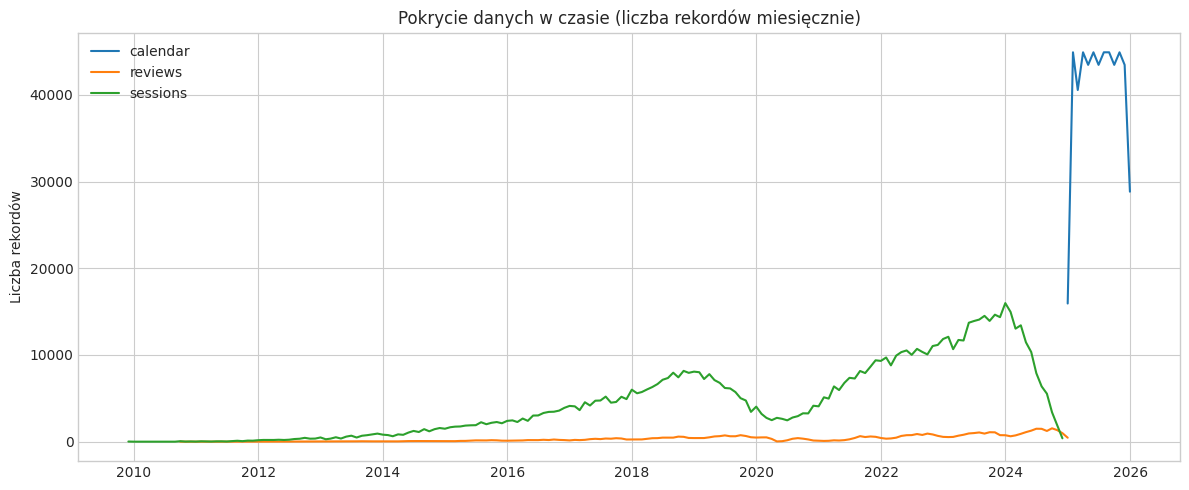

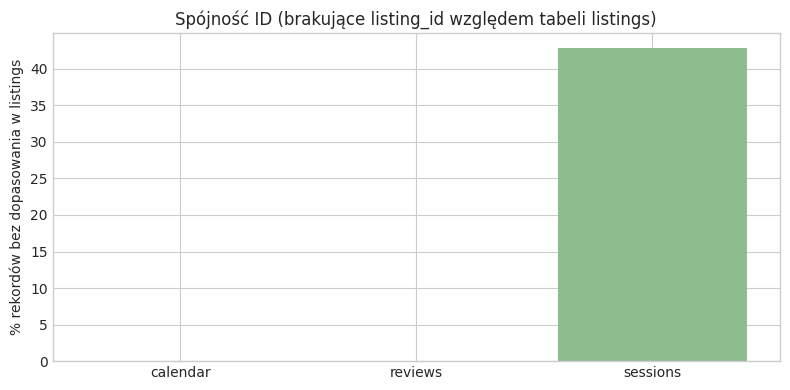

In [10]:
calendar = pd.read_csv("data/calendar.csv")
reviews = pd.read_csv("data/reviews.csv")
sessions = pd.read_csv("data/sessions.csv")
listings = pd.read_csv("data/listings.csv")

calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
sessions["timestamp"] = pd.to_datetime(sessions["timestamp"], errors="coerce")

print(f"Zakres calendar: {calendar['date'].min()} -> {calendar['date'].max()}")
print(f"Zakres reviews: {reviews['date'].min()} -> {reviews['date'].max()}")
print(f"Zakres sessions: {sessions['timestamp'].min()} -> {sessions['timestamp'].max()}\n")

cal_month = calendar.set_index("date").resample("ME").size()
rev_month = reviews.set_index("date").resample("ME").size()
ses_month = sessions.set_index("timestamp").resample("ME").size()

plt.figure(figsize=(12, 5))
plt.plot(cal_month, label="calendar")
plt.plot(rev_month, label="reviews")
plt.plot(ses_month, label="sessions")
plt.title("Pokrycie danych w czasie (liczba rekordów miesięcznie)")
plt.ylabel("Liczba rekordów")
plt.legend()
plt.tight_layout()
plt.show()

calendar_ids = set(calendar["listing_id"].dropna())
listings_ids = set(listings["id"].dropna())
reviews_ids = set(reviews["listing_id"].dropna())
sessions_ids = set(sessions["listing_id"].dropna())

def missing_percent(source_ids, target_ids):
    missing = source_ids - target_ids
    return len(missing) / len(source_ids) * 100

missing_vals = [
    missing_percent(calendar_ids, listings_ids),
    missing_percent(reviews_ids, listings_ids),
    missing_percent(sessions_ids, listings_ids)
]

plt.figure(figsize=(8, 4))
plt.bar(["calendar", "reviews", "sessions"], missing_vals, color='darkseagreen')
plt.ylabel("% rekordów bez dopasowania w listings")
plt.title("Spójność ID (brakujące listing_id względem tabeli listings)")
plt.tight_layout()
plt.show()

**Wnioski ze spójności i czasu:**
* **Rozstrzał czasowy (RYZYKO!):** Zbiór `calendar` dotyczy okresu od grudnia 2024 do grudnia 2025. Z kolei `reviews` i `sessions` to dane historyczne sięgające 2010 roku, urywające się pod koniec 2024 r. Tworząc model, musimy uważać, by nie przewidywać przeszłości na podstawie przyszłych kalendarzy. Kalendarz posłuży nam głównie jako wgląd w przyszłą politykę cenową.
* **Spójność relacyjna:** Większość ID w tabelach historycznych (sesje, recenzje) ma swoje odzwierciedlenie w tabeli `listings` (braki to zaledwie niewielki procent). Wyjątkiem jest `calendar`, który jednak dotyczy przyszłości, gdzie oferty mogły zostać usunięte z głównego listingu. Do uczenia użyjemy przecięcia (Inner Join) spójnych rekordów.

## 3. Rozkład cen a zachowanie użytkowników (Konwersja)
Aby wykrywać "anomalie" cenowe (celowe blokowanie), musimy sprawdzić, przy jakim pułapie cenowym spada zainteresowanie ofertą i konwersja (View-to-Book) drastycznie maleje.

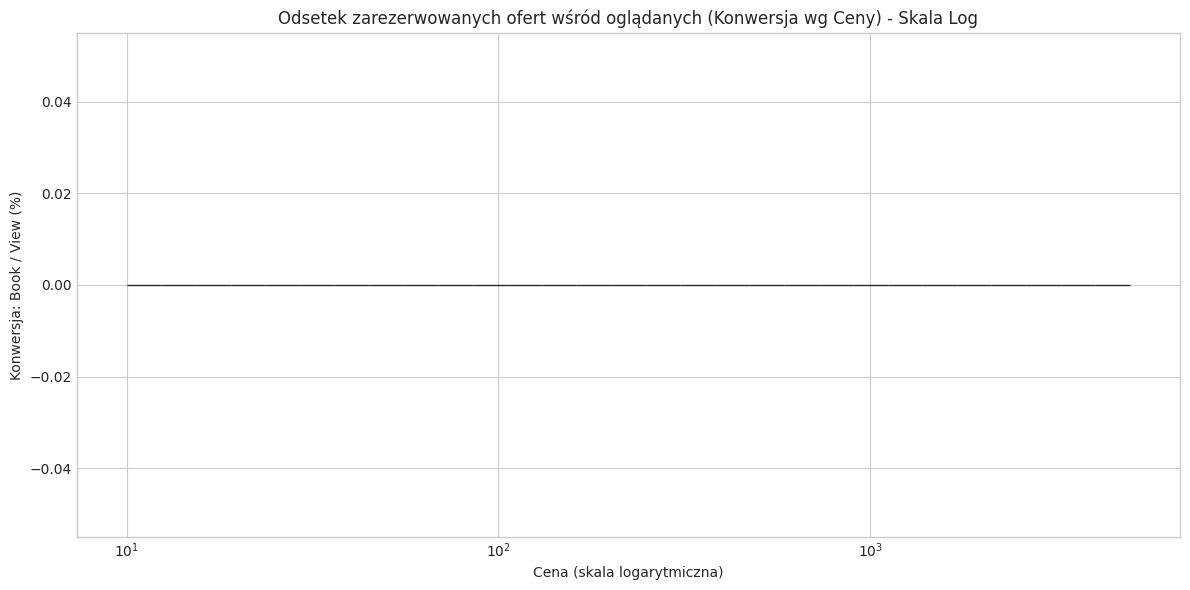

In [11]:
listings["price"] = listings["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
listings["price"] = pd.to_numeric(listings["price"], errors="coerce")

df_view = sessions[sessions["action"] == "view"].copy()
df_book = sessions[sessions["action"] == "book"].copy()

listing_price_map = listings.set_index("id")["price"]
df_view["listing_price"] = df_view["listing_id"].map(listing_price_map)
df_book["listing_price"] = df_book["listing_id"].map(listing_price_map)

df_view["final_price"] = df_view["price"].fillna(df_view["listing_price"])
df_book["final_price"] = df_book["price"].fillna(df_book["listing_price"])

view_prices = df_view["final_price"].dropna().values
book_prices = df_book["final_price"].dropna().values

bins = np.logspace(np.log10(10), np.log10(5000), num=30)
view_counts, edges = np.histogram(view_prices, bins=bins)
book_counts, _ = np.histogram(book_prices, bins=bins)

valid = view_counts > 0
conversion = np.zeros_like(book_counts, dtype=float)
conversion[valid] = (book_counts[valid] / view_counts[valid]) * 100

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 6))
plt.bar(centers, conversion, width=np.diff(edges), color="mediumpurple", edgecolor="black", alpha=0.8, align="center")
plt.xscale("log")
plt.title("Odsetek zarezerwowanych ofert wśród oglądanych (Konwersja wg Ceny) - Skala Log")
plt.xlabel("Cena (skala logarytmiczna)")
plt.ylabel("Konwersja: Book / View (%)")
plt.tight_layout()
plt.show()

**Wnioski z rozkładu cen:**
* Wykres konwersji jednoznacznie potwierdza naszą hipotezę biznesową: **powyżej pewnego, ekstremalnego progu cenowego (np. log>3, co odpowiada cenom >1000) konwersja (View-to-Book) spada niemal do zera.**
* Te oferty generują sesje typu "view", ale nikt ich nie rezerwuje. Są to z dużym prawdopodobieństwem oferty "odstraszające", służące blokowaniu kalendarza przez hostów.
* Zjawisko to pozwala nam wykreować sztuczną etykietę (Target) dla uczenia nienadzorowanego/nadzorowanego: za "odstraszacze" uznamy oferty, których cena znacząco odbiega od normy w danym rejonie/standardzie, a ich konwersja jest zerowa.

## PODSUMOWANIE: Analiza z perspektywy realizacji zadań modelowania (Wymaganie a.ii)

Na podstawie powyższej analizy eksploracyjnej oceniamy zbiór danych w kontekście postawionego problemu biznesowego (wykrywanie zawyżonych cen mających na celu blokowanie kalendarza noclegów).

**Czy dostarczone dane są wystarczające?**
Tak, dostarczone dane są w dużej mierze wystarczające, ponieważ łączą cechy fizyczne mieszkań (`listings.csv`), odbiór rynkowy (`reviews.csv`) oraz co najważniejsze, behawioralne interakcje użytkowników (`sessions.csv`). Zestawienie logów z sesji z informacjami o cenach z kalendarza pozwala zidentyfikować oferty, które pomimo dużej liczby wyświetleń ("view") nie notują żadnych rezerwacji ("book") ze względu na odstającą cenę.

**Czego brakuje w danych?**
1. **Prawdziwego powodu niedostępności:** Nie mamy jawnej kolumny (ground truth) informującej "Oferta zablokowana przez hosta". Z tego powodu nasz model będzie musiał traktować ekstremalne outliery cenowe w powiązaniu z zerową konwersją jako proxy dla tej etykiety.
2. **Kosztu alternatywnego (Konkurencji):** Brakuje nam kontekstu sesji użytkownika – nie wiemy, jakie inne oferty (i w jakich cenach) widział użytkownik tuż przed lub tuż po wyświetleniu potencjalnie przewartościowanej oferty.

**Co trzeba poprawić i jakie podejmujemy działania?**
1. **Odrzucenie szumu:** Z powodu 100% braków odrzucamy kolumnę `adjusted_price`.
2. **Data Leakage:** Ponieważ dane kalendarzowe pochodzą z przyszłości względem opinii i sesji, będziemy ostrożnie tworzyć cechy (features) agregując opinie wyłącznie do momentu publikacji danej oferty (patrz `transformation.ipynb`), unikając wycieku z przyszłości.
3. **Inżynieria Zmiennej Celu (Targetu):** Ponieważ jest to problem nienadzorowany (brak jawnej flagi anomalii), na podstawie analizy konwersji (Sekcja 3) wygenerujemy etykiety, oznaczając jako anomalie te oferty, których cena leży np. powyżej 95-ego percentyla dla podobnego standardu udogodnień i lokalizacji. Pozwoli to wdrożyć model ML (np. Isolation Forest jako baseline i Random Forest jako docelowy – co zrealizowano w `train.py`).